In [4]:
# Imports
from functools import partial
import re
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import Aer, BasicAer
from qiskit.utils import QuantumInstance, algorithm_globals
from qiskit.algorithms.optimizers import SLSQP, COBYLA
from qiskit.algorithms.minimum_eigen_solvers import NumPyMinimumEigensolver, VQE
from qiskit.algorithms import NumPyEigensolver
from qiskit.circuit.library import ExcitationPreserving

from qiskit_nature.problems.second_quantization import ElectronicStructureProblem
from qiskit_nature.converters.second_quantization import QubitConverter
from qiskit_nature.mappers.second_quantization import JordanWignerMapper, ParityMapper
from qiskit_nature.algorithms import GroundStateEigensolver
from qiskit_nature.algorithms import ExcitedStatesEigensolver
from qiskit_nature.drivers import UnitsType, Molecule
from qiskit_nature.drivers.second_quantization import ElectronicStructureDriverType, ElectronicStructureMoleculeDriver
from qiskit_nature.drivers.second_quantization import FCIDumpDriver

In [5]:
qubit_converter = QubitConverter(JordanWignerMapper(), two_qubit_reduction=True)
quantum_instance = QuantumInstance(backend=Aer.get_backend("aer_simulator_statevector"))

In [6]:
# Get a list of FCIDUMP files for SbH with different bond length
root = r"/home/ola/quantum_computing/SbH/opfermion/"
molecules = [(float(d)/100, root + d + "/FCIDUMP") for d in os.listdir(root) if re.match("\d\d\d", d)]
molecules.sort(key=lambda x: x[0])
molecules

[(1.3, '/home/ola/quantum_computing/SbH/opfermion/130/FCIDUMP'),
 (1.4, '/home/ola/quantum_computing/SbH/opfermion/140/FCIDUMP'),
 (1.5, '/home/ola/quantum_computing/SbH/opfermion/150/FCIDUMP'),
 (1.6, '/home/ola/quantum_computing/SbH/opfermion/160/FCIDUMP'),
 (1.65, '/home/ola/quantum_computing/SbH/opfermion/165/FCIDUMP'),
 (1.7, '/home/ola/quantum_computing/SbH/opfermion/170/FCIDUMP'),
 (1.75, '/home/ola/quantum_computing/SbH/opfermion/175/FCIDUMP'),
 (1.8, '/home/ola/quantum_computing/SbH/opfermion/180/FCIDUMP'),
 (1.85, '/home/ola/quantum_computing/SbH/opfermion/185/FCIDUMP'),
 (1.9, '/home/ola/quantum_computing/SbH/opfermion/190/FCIDUMP'),
 (2.0, '/home/ola/quantum_computing/SbH/opfermion/200/FCIDUMP'),
 (2.1, '/home/ola/quantum_computing/SbH/opfermion/210/FCIDUMP'),
 (2.2, '/home/ola/quantum_computing/SbH/opfermion/220/FCIDUMP'),
 (2.3, '/home/ola/quantum_computing/SbH/opfermion/230/FCIDUMP'),
 (2.4, '/home/ola/quantum_computing/SbH/opfermion/240/FCIDUMP'),
 (2.6, '/home/ola/quan

In [7]:
# Exact GS
gs_solver_numpy = GroundStateEigensolver(qubit_converter, NumPyMinimumEigensolver())

point_exact = []
energy_exact = []
result_exact = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    result = gs_solver_numpy.solve(problem)
    point_exact.append(bond_length)
    energy_exact.append(result.total_energies[0])
    result_exact.append(result)
    #print("RESULT", point_exact, energy_exact)

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbit

In [15]:
# Exact exicted states
es_solver_numpy = ExcitedStatesEigensolver(qubit_converter, NumPyEigensolver(k=4))

point_exact_exc = []
energy_exact_exc = []
result_exact_exc = []

bond_length, fcidump = molecules[5]
driver = FCIDumpDriver(fcidump, relativistic=True)
problem = ElectronicStructureProblem(driver=driver)
result = es_solver_numpy.solve(problem)
result.total_energies

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2


array([-6481.30023143+0.j, -6481.30023143+0.j, -6481.29942344+0.j,
       -6481.297734  +0.j])

In [62]:
# Exact exicted states
es_solver_numpy = ExcitedStatesEigensolver(qubit_converter, NumPyEigensolver(k=14))

point_exc = []
energy_exc0 = []
energy_exc1 = []
energy_exc2 = []
energy_exc3 = []
energy_exc4 = []
energy_exc5 = []
energy_exc6 = []
energy_exc7 = []
energy_exc8 = []
energy_exc9 = []
energy_exc10 = []
energy_exc11 = []
energy_exc12 = []
energy_exc13 = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    result = es_solver_numpy.solve(problem)
    point_exc.append(bond_length)
    energy_exc0.append(result.total_energies[0])
    energy_exc1.append(result.total_energies[1])
    energy_exc2.append(result.total_energies[2])
    energy_exc3.append(result.total_energies[3])
    energy_exc4.append(result.total_energies[4])
    energy_exc5.append(result.total_energies[5])
    energy_exc6.append(result.total_energies[6])
    energy_exc7.append(result.total_energies[7])
    energy_exc8.append(result.total_energies[8])
    energy_exc9.append(result.total_energies[9])
    energy_exc10.append(result.total_energies[10])
    energy_exc11.append(result.total_energies[11])
    energy_exc12.append(result.total_energies[12])
    energy_exc13.append(result.total_energies[13])

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbit

/home/ola/miniconda3/envs/qiskit037/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Energy')

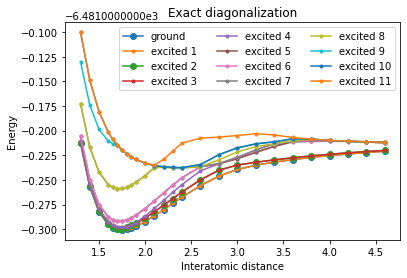

In [67]:
#plt.plot(point_exact, energy_exact, marker="o", label="exact")
plt.plot(point_exc, energy_exc0, marker="o", label="ground")
plt.plot(point_exc, energy_exc1, marker=".", label="excited 1")
plt.plot(point_exc, energy_exc2, marker="o", label="excited 2")
plt.plot(point_exc, energy_exc3, marker=".", label="excited 3")
plt.plot(point_exc, energy_exc4, marker=".", label="excited 4")
plt.plot(point_exc, energy_exc5, marker=".", label="excited 5")
plt.plot(point_exc, energy_exc6, marker=".", label="excited 6")
plt.plot(point_exc, energy_exc7, marker=".", label="excited 7")
plt.plot(point_exc, energy_exc8, marker=".", label="excited 8")
plt.plot(point_exc, energy_exc9, marker=".", label="excited 9")
plt.plot(point_exc, energy_exc10, marker=".", label="excited 10")
plt.plot(point_exc, energy_exc11, marker=".", label="excited 11")
plt.title("Exact diagonalization")
plt.legend(ncol=3)
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")

In [72]:
# VQE initial guess
solver_vqe = VQE(quantum_instance=quantum_instance)
gs_solver_vqe = GroundStateEigensolver(qubit_converter, solver_vqe)

results_vqe = []

bond_length, fcidump = molecules[6]
driver = FCIDumpDriver(fcidump, relativistic=True)
problem = ElectronicStructureProblem(driver=driver)

for i in range(100):
    solver_vqe.initial_point = np.random.rand(32)
    results_vqe.append(gs_solver_vqe.solve(problem))

vqe = min(results_vqe, key=lambda x: x.total_energies[0])
solver_vqe.initial_point = vqe.raw_result.optimal_point

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbit

In [73]:
solver_vqe.initial_point = vqe.raw_result.optimal_point.copy()

In [74]:
#solver_vqe = VQE(quantum_instance=quantum_instance)
gs_solver_vqe = GroundStateEigensolver(qubit_converter, solver_vqe)

point_vqe = []
energy_vqe = []
results_vqe = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    vqe_1 = gs_solver_vqe.solve(problem)
    results_vqe.append(vqe_1)
    point_vqe.append(bond_length)
    energy_vqe.append(vqe_1.total_energies[0])
    solver_vqe.initial_point = vqe_1.raw_result.optimal_point

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbit

/home/ola/miniconda3/envs/qiskit037/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'Energy')

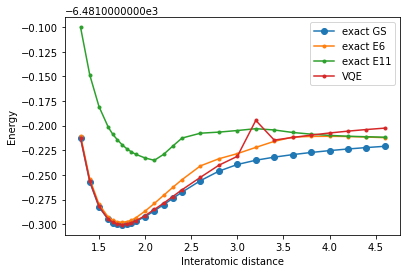

In [75]:
plt.plot(point_exact, energy_exact, marker="o", label="exact GS")
plt.plot(point_exc, energy_exc4, marker=".", label="exact E6")
plt.plot(point_exc, energy_exc11, marker=".", label="exact E11")
plt.plot(point_vqe, energy_vqe, marker=".", label="VQE")
plt.legend()
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")

In [76]:
#from qiskit_nature.algorithms.ground_state_solvers import AdaptVQE
from qiskit.algorithms.optimizers import COBYLA

solver_vqe2 = VQE(quantum_instance=quantum_instance, optimizer=COBYLA(maxiter=10000))
gs_solver_vqe2 = GroundStateEigensolver(qubit_converter, solver_vqe2)
solver_vqe2.initial_point = vqe.raw_result.optimal_point.copy()

point_vqe2 = []
energy_vqe2 = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    result = gs_solver_vqe2.solve(problem)
    point_vqe2.append(bond_length)
    energy_vqe2.append(result.total_energies[0])
    solver_vqe2.initial_point = result.raw_result.optimal_point


We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbit

Text(0, 0.5, 'Energy')

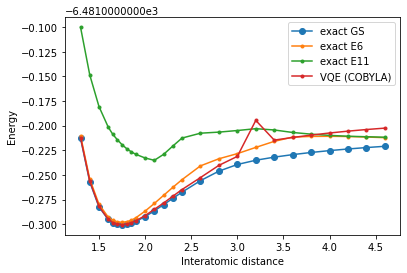

In [77]:
plt.plot(point_exact, energy_exact, marker="o", label="exact GS")
plt.plot(point_exc, energy_exc4, marker=".", label="exact E6")
plt.plot(point_exc, energy_exc11, marker=".", label="exact E11")
plt.plot(point_vqe2, energy_vqe2, marker=".", label="VQE (COBYLA)")
plt.legend()
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")

In [79]:
#from qiskit_nature.algorithms.ground_state_solvers import AdaptVQE
from qiskit.algorithms.optimizers import SLSQP

solver_vqe3 = VQE(quantum_instance=quantum_instance, optimizer=SLSQP(maxiter=10000))
solver_vqe3.initial_point = vqe.raw_result.optimal_point.copy()
gs_solver_vqe3 = GroundStateEigensolver(qubit_converter, solver_vqe3)

point_vqe3 = []
energy_vqe3 = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    result = gs_solver_vqe3.solve(problem)
    point_vqe3.append(bond_length)
    energy_vqe3.append(result.total_energies[0])
    solver_vqe3.initial_point = result.raw_result.optimal_point.copy()

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbit

/home/ola/miniconda3/envs/qiskit037/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1298: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


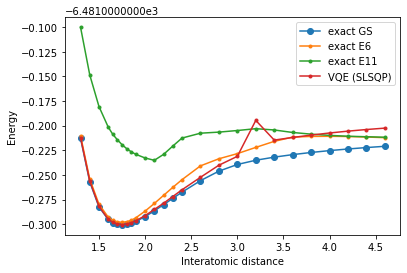

In [80]:
plt.plot(point_exact, energy_exact, marker="o", label="exact GS")
plt.plot(point_exc, energy_exc4, marker=".", label="exact E6")
plt.plot(point_exc, energy_exc11, marker=".", label="exact E11")
plt.plot(point_vqe3, energy_vqe3, marker=".", label="VQE (SLSQP)")
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")
plt.legend()

In [59]:
from qiskit.algorithms.optimizers import ADAM

solver_vqe4 = VQE(quantum_instance=quantum_instance, optimizer=ADAM(maxiter=50))
solver_vqe4.initial_point = vqe.raw_result.optimal_point.copy()
gs_solver_vqe4 = GroundStateEigensolver(qubit_converter, solver_vqe3)

point_vqe4 = []
energy_vqe4 = []

for bond_length, fcidump in molecules:
    driver = FCIDumpDriver(fcidump, relativistic=True)
    problem = ElectronicStructureProblem(driver=driver)
    result = gs_solver_vqe4.solve(problem)
    point_vqe4.append(bond_length)
    energy_vqe4.append(result.total_energies[0])

We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbital occupation: [1. 1. 0. 0.]
num_alpha = 2
num_beta = 2
We have relativistic calculations: True
We have relativistic intergrals.
FCIDumpDriver
particle_number = ParticleNumber:
	8 SOs
	2 alpha electrons
		orbital occupation: [1. 1. 0. 0.]
	2 beta electrons
		orbit

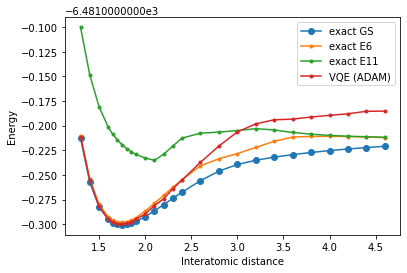

In [71]:
plt.plot(point_exact, energy_exact, marker="o", label="exact GS")
plt.plot(point_exc, energy_exc4, marker=".", label="exact E6")
plt.plot(point_exc, energy_exc11, marker=".", label="exact E11")
plt.plot(point_vqe4, energy_vqe4, marker=".", label="VQE (ADAM)")
plt.xlabel("Interatomic distance")
plt.ylabel("Energy")
plt.legend()